In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Load the JSON file
with open('l2r_CBCT_results_full.json', 'r') as f:
    data = json.load(f)


In [9]:
# Process the data
experiments = data['experiments']

results = []
for experiment in experiments:
    name = experiment['name']
    for result in experiment['results']:
        epoch = result['epoch']
        dsc_mean = result['DSC']['mean']
        dsc_std = result['DSC']['std']
        hd95_mean = result['HD95']['mean']
        hd95_std = result['HD95']['std']
        tre_kp_mean = result['TRE_kp']['mean']
        tre_kp_std = result['TRE_kp']['std']
        log_jac_det_std_mean = result['LogJacDetStd']['mean']
        log_jac_det_std_std = result['LogJacDetStd']['std']
        num_foldings_mean = result['num_foldings']['mean']
        num_foldings_std = result['num_foldings']['std']
        results.append([name, epoch, dsc_mean, dsc_std, hd95_mean, hd95_std, tre_kp_mean, tre_kp_std, log_jac_det_std_mean, log_jac_det_std_std, num_foldings_mean, num_foldings_std])

# Create a DataFrame
df = pd.DataFrame(results, columns=['Experiment', 'Epoch', 'DSC Mean', 'DSC Std', 'HD95 Mean', 'HD95 Std', 'TRE_kp Mean', 'TRE_kp Std', 'LogJacDetStd Mean', 'LogJacDetStd Std', 'Num Foldings Mean', 'Num Foldings Std'])

df = df.sort_values(by='Epoch')

# Get the value of the last item for 'finetune'
finetune_last_value = df[df['Experiment'] == 'Finetune']['DSC Mean'].iloc[-1]
fromzero_last_value = df[df['Experiment'] == 'Train from Scratch']['DSC Mean'].iloc[-1]

6       0
5     200
4     400
3     800
2    1600
1    3200
0    3800
Name: Epoch, dtype: int64
13       0
12     200
11     400
10     800
9     1600
8     3200
7     3800
14    4300
15    4800
16    5800
17    6800
18    7600
Name: Epoch, dtype: int64


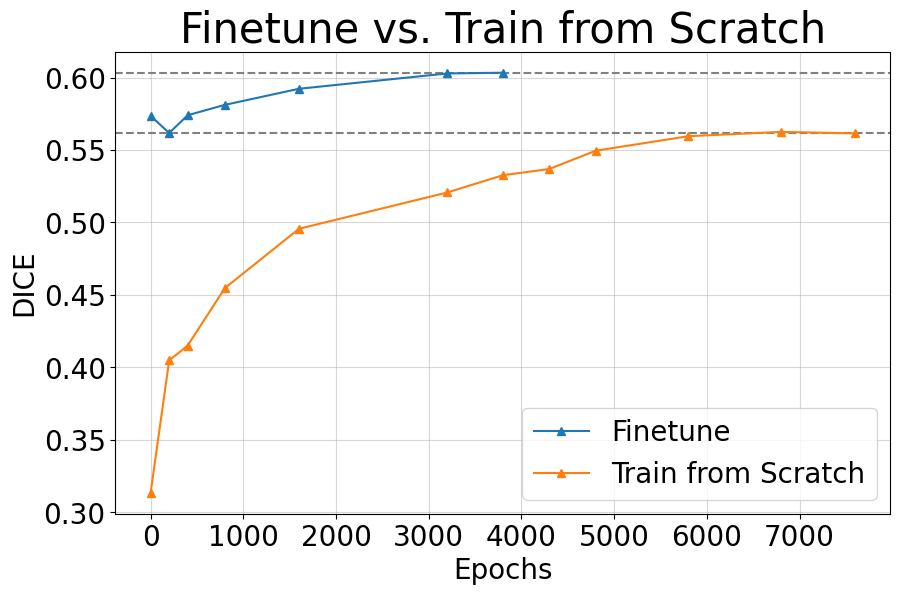

In [13]:
# Plotting the data
plt.figure(figsize=(10, 6))

base_font_size = 20

# Draw a dotted line at the value of the last item for 'finetune' and 'Train from Scratch'
plt.axhline(y=finetune_last_value, color='gray', linestyle='--')#, label=f'Finetune Last Value: {finetune_last_value:.2f}')
plt.axhline(y=fromzero_last_value, color='gray', linestyle='--')#, label=f'Finetune Last Value: {finetune_last_value:.2f}')

for experiment in df['Experiment'].unique():
    exp_data = df[df['Experiment'] == experiment]
    print(exp_data['Epoch'])
    plt.plot(exp_data['Epoch'], exp_data['DSC Mean'], marker='^', label=experiment)

# Customizing the plot
plt.xlabel('Epochs', fontsize=base_font_size)
plt.ylabel('DICE', fontsize=base_font_size)
# plt.xscale('log')
plt.title('Finetune vs. Train from Scratch', fontsize=int(base_font_size*1.5))
plt.legend(fontsize=base_font_size)
plt.grid(alpha=0.5)
# plt.tight_layout()

# Increase tick font size
plt.tick_params(axis='both', which='major', labelsize=base_font_size)

# Show the plot
# plt.show()
plt.savefig('l2r_CBCT_finetune_vs_from_scratch.png', dpi=200, bbox_inches='tight')